In [1]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print(filename)

Saving test.csv to test (1).csv
Saving training.csv to training (1).csv
Saving validation.csv to validation (1).csv

Uploaded files:
test (1).csv
training (1).csv
validation (1).csv


In [4]:
import os

print("Files in Colab:")
print(os.listdir("/content"))

Files in Colab:
['.config', 'test.csv', 'training.csv', 'validation.csv', 'training (1).csv', 'test (1).csv', 'validation (1).csv', 'sample_data']


In [6]:
train_df = pd.read_csv("/content/training.csv")
test_df = pd.read_csv("/content/test.csv")
validation_df = pd.read_csv("/content/validation.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Validation shape:", validation_df.shape)

Train shape: (16000, 2)
Test shape: (2000, 2)
Validation shape: (2000, 2)


In [7]:
print("TRAIN COLUMNS:")
print(train_df.columns.tolist())

print("\nTEST COLUMNS:")
print(test_df.columns.tolist())

print("\nVALIDATION COLUMNS:")
print(validation_df.columns.tolist())

TRAIN COLUMNS:
['text', 'label']

TEST COLUMNS:
['text', 'label']

VALIDATION COLUMNS:
['text', 'label']


In [8]:
print("\nFirst 5 rows of training data:")
display(train_df.head())


First 5 rows of training data:


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [9]:
print("Available columns:", train_df.columns.tolist())

# Possible names for text column
text_candidates = [
    "text", "Text", "sentence", "Sentence",
    "content", "Content", "utterance", "Utterance"
]

# Possible names for emotion/label column
label_candidates = [
    "emotion", "Emotion", "label", "Label",
    "sentiment", "Sentiment", "category", "Category"
]

TEXT_COLUMN = None
LABEL_COLUMN = None

for col in text_candidates:
    if col in train_df.columns:
        TEXT_COLUMN = col
        break

for col in label_candidates:
    if col in train_df.columns:
        LABEL_COLUMN = col
        break

print("Detected text column:", TEXT_COLUMN)
print("Detected emotion column:", LABEL_COLUMN)

Available columns: ['text', 'label']
Detected text column: text
Detected emotion column: label


In [10]:
train_df = train_df[['text', 'label']].copy()
test_df = test_df[['text', 'label']].copy()
validation_df = validation_df[['text', 'label']].copy()

# Remove missing values
train_df.dropna(inplace=True)
test_df.dropna(inplace=True)
validation_df.dropna(inplace=True)

# Convert to string
train_df['text'] = train_df['text'].astype(str)
test_df['text'] = test_df['text'].astype(str)
validation_df['text'] = validation_df['text'].astype(str)

train_df['label'] = train_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)

validation_df['label'] = validation_df['label'].astype(str)

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))
print("Validation samples:", len(validation_df))

Training samples: 16000
Testing samples: 2000
Validation samples: 2000


In [11]:
print("Emotion labels:")

for emotion in sorted(train_df['label'].unique()):
    print(emotion)

print("\nTotal number of emotions:",
      train_df['label'].nunique())

Emotion labels:
0
1
2
3
4
5

Total number of emotions: 6


In [12]:
display(train_df.head(10))

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
5,ive been feeling a little burdened lately wasn...,0
6,ive been taking or milligrams or times recomme...,5
7,i feel as confused about life as a teenager or...,4
8,i have been with petronas for years i feel tha...,1
9,i feel romantic too,2


In [13]:
X_train = train_df['text']
y_train = train_df['label']

X_test = test_df['text']
y_test = test_df['label']

X_validation = validation_df['text']
y_validation = validation_df['label']

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

X_train: (16000,)
y_train: (16000,)
X_test: (2000,)
y_test: (2000,)
X_validation: (2000,)
y_validation: (2000,)


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

X_validation_tfidf = tfidf.transform(X_validation)

print("TF-IDF conversion completed!")

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)
print("Validation shape:", X_validation_tfidf.shape)

TF-IDF conversion completed!
Training shape: (16000, 10000)
Testing shape: (2000, 10000)
Validation shape: (2000, 10000)


In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train_tfidf, y_train)

print("Emotion Recognition Model trained successfully!")

Emotion Recognition Model trained successfully!


In [16]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", round(accuracy * 100, 2), "%")

Test Accuracy: 88.8 %


In [17]:
y_val_pred = model.predict(X_validation_tfidf)

validation_accuracy = accuracy_score(
    y_validation,
    y_val_pred
)

print("Validation Accuracy:",
      round(validation_accuracy * 100, 2), "%")

Validation Accuracy: 89.1 %


In [18]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       581
           1       0.86      0.96      0.91       695
           2       0.82      0.65      0.73       159
           3       0.92      0.83      0.87       275
           4       0.90      0.86      0.88       224
           5       0.94      0.52      0.67        66

    accuracy                           0.89      2000
   macro avg       0.89      0.79      0.83      2000
weighted avg       0.89      0.89      0.88      2000



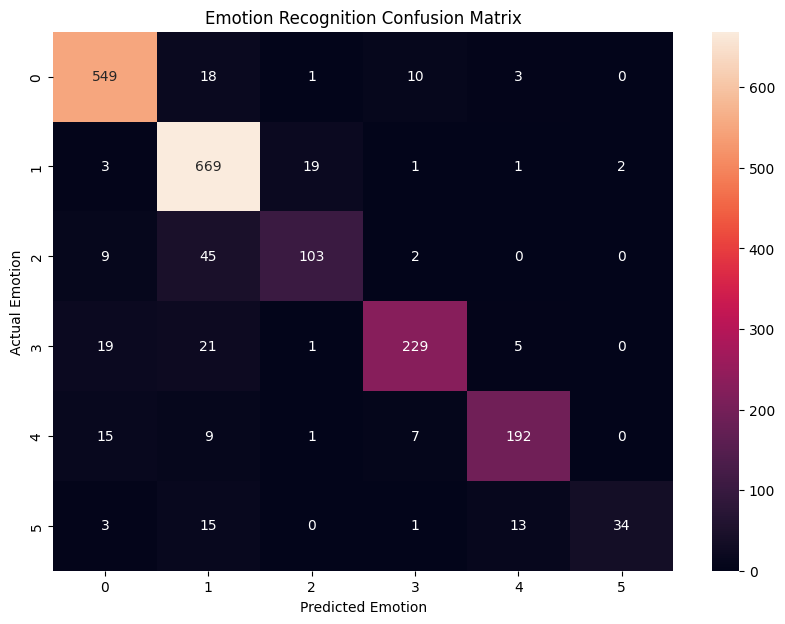

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = sorted(train_df['label'].unique())

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("Emotion Recognition Confusion Matrix")

plt.show()

In [24]:
def predict_emotion(text):
    text_tfidf = tfidf.transform([text])
    prediction = model.predict(text_tfidf)[0]

    return prediction

In [25]:
text = input("Enter a sentence: ")

emotion = predict_emotion(text)

print("\nPredicted Emotion:", emotion)

Enter a sentence: i am very happy today

Predicted Emotion: 1


In [26]:
def predict_emotion_with_confidence(text):

    text_tfidf = tfidf.transform([text])

    probabilities = model.predict_proba(text_tfidf)[0]

    index = np.argmax(probabilities)

    emotion = model.classes_[index]

    confidence = probabilities[index] * 100

    return emotion, confidence

In [27]:
text = input("Enter a sentence: ")

emotion, confidence = predict_emotion_with_confidence(text)

print("\n==============================")
print("   EMOTION RECOGNITION")
print("==============================")
print("Input Text:", text)
print("Predicted Emotion:", emotion)
print("Confidence:", round(confidence, 2), "%")

Enter a sentence: i am very happy today

   EMOTION RECOGNITION
Input Text: i am very happy today
Predicted Emotion: 1
Confidence: 85.11 %


In [28]:
sentences = [
    "I am extremely happy today",
    "I am very angry with him",
    "I am scared about what will happen",
    "I feel lonely and sad",
    "I love spending time with my family",
    "Wow, I did not expect this"
]

for sentence in sentences:

    emotion, confidence = predict_emotion_with_confidence(sentence)

    print("--------------------------------")
    print("Text:", sentence)
    print("Emotion:", emotion)
    print("Confidence:", round(confidence, 2), "%")

--------------------------------
Text: I am extremely happy today
Emotion: 1
Confidence: 67.45 %
--------------------------------
Text: I am very angry with him
Emotion: 3
Confidence: 96.83 %
--------------------------------
Text: I am scared about what will happen
Emotion: 4
Confidence: 85.1 %
--------------------------------
Text: I feel lonely and sad
Emotion: 0
Confidence: 96.86 %
--------------------------------
Text: I love spending time with my family
Emotion: 1
Confidence: 43.71 %
--------------------------------
Text: Wow, I did not expect this
Emotion: 1
Confidence: 44.34 %
